# Mongo EDA — fleet_operations

Profiles the 3 live collections (`delivery_events`, `maintenance_records`, `safety_incidents`): row counts, nulls, key uniqueness, dates, sums, splits. Fills `docs/FINDINGS.md` rows 1–3.

In [1]:
# setup: paths, plotting theme, output folders
import json
from pathlib import Path

import matplotlib

matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style='whitegrid')
cwd = Path.cwd()
ROOT = cwd if (cwd / 'notebooks').is_dir() else cwd.parent
PLOTS = ROOT / 'notebooks' / 'plots'
PLOTS.mkdir(exist_ok=True)
import sys

sys.path.insert(0, str(ROOT))

In [2]:
# load the 3 collections, _id carries no analysis value
from src.utils import get_mongo_database

db = get_mongo_database()
frames = {}
for name in ['delivery_events', 'maintenance_records', 'safety_incidents']:
    frame = pd.DataFrame(list(db[name].find())).drop(columns=['_id'], errors='ignore')
    frames[name] = frame
    print(name, frame.shape)

2026-10-05 14:23:16,139 INFO src.utils.connection: mongo connected db=fleet_operations


delivery_events (170820, 12)
maintenance_records (2920, 13)
safety_incidents (170, 16)


In [3]:
# per-table profile: nulls, uniques, numeric and date summaries
def profile(frame):
    cols = {}
    for c in frame.columns:
        s = frame[c]
        info = {'null_pct': round(float(s.isna().mean()) * 100, 2), 'uniques': int(s.nunique(dropna=True))}
        num = pd.to_numeric(s, errors='coerce')
        if num.notna().mean() >= 0.95 and info['uniques'] > 2:
            info['sum'] = round(float(num.sum()), 2)
            info['mean'] = round(float(num.mean()), 2)
            info['min'], info['max'] = round(float(num.min()), 2), round(float(num.max()), 2)
        if s.dtype == object:
            d = pd.to_datetime(s, errors='coerce', format='mixed')
            if d.notna().mean() >= 0.90:
                info['dmin'], info['dmax'] = str(d.min()), str(d.max())
        cols[str(c)] = info
    return {'rows': len(frame), 'dupe_rows': int(frame.duplicated().sum()), 'columns': cols}


stats = {name: profile(frame) for name, frame in frames.items()}
for name, st in stats.items():
    bad = {c: v['null_pct'] for c, v in st['columns'].items() if v['null_pct'] > 0}
    print(name, 'rows=', st['rows'], 'dupes=', st['dupe_rows'], 'nulls>', bad)

delivery_events rows= 170820 dupes= 0 nulls> {}
maintenance_records rows= 2920 dupes= 0 nulls> {}
safety_incidents rows= 170 dupes= 0 nulls> {'truck_id': 0.59, 'driver_id': 0.59}


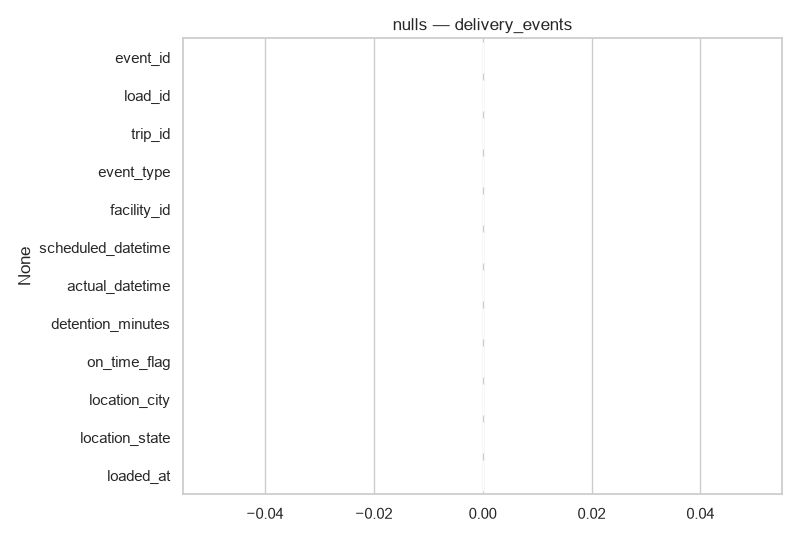

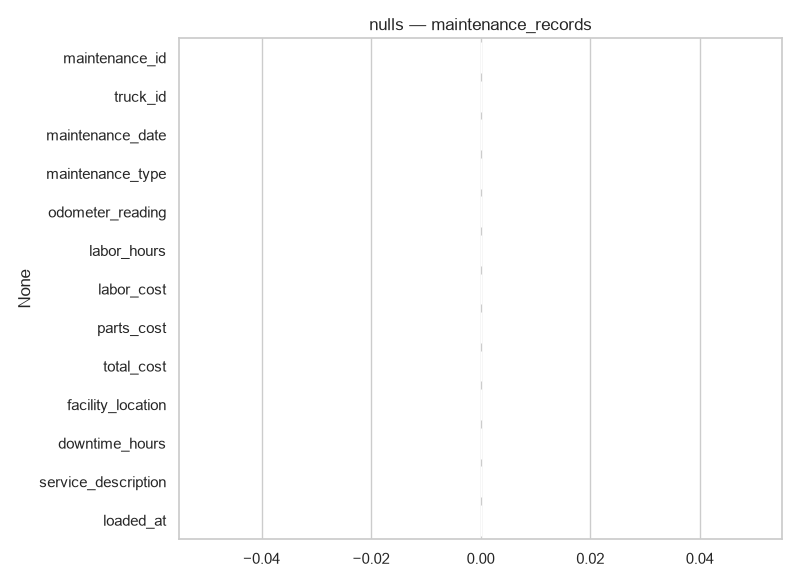

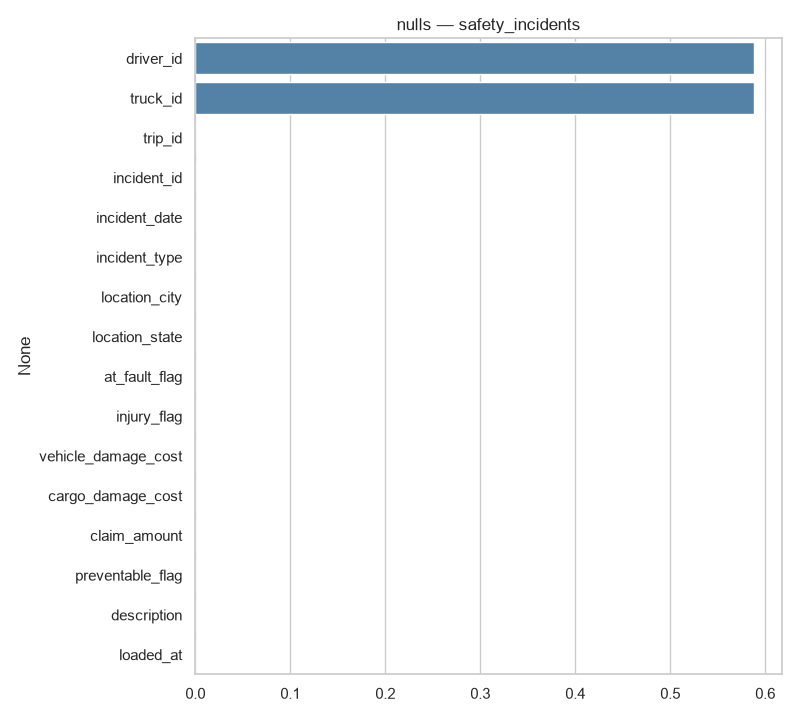

In [4]:
# null-share bar per collection
for name, frame in frames.items():
    vals = frame.isna().mean().mul(100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(3, len(vals) * 0.45)))
    sns.barplot(x=vals.values, y=vals.index, ax=ax, color='steelblue')
    ax.set_title(f'nulls — {name}')
    fig.tight_layout()
    path = PLOTS / f'nulls_{name}.png'
    fig.savefig(path, dpi=100)
    plt.close(fig)
    display(Image(str(path)))

In [5]:
# key uniqueness on the candidate primary keys
for name, key in [('delivery_events', 'event_id'), ('maintenance_records', 'maintenance_id'), ('safety_incidents', 'incident_id')]:
    dupes = int(frames[name].duplicated(subset=[key]).sum())
    stats[name]['key_dupes'] = dupes
    print(name, key, 'dupe_rows=', dupes)

delivery_events event_id dupe_rows= 0
maintenance_records maintenance_id dupe_rows= 0
safety_incidents incident_id dupe_rows= 0


In [6]:
# date ranges and numeric sums that matter
ev = frames['delivery_events']
print('scheduled:', ev['scheduled_datetime'].min(), '->', ev['scheduled_datetime'].max())
print('actual:', ev['actual_datetime'].min(), '->', ev['actual_datetime'].max())
print('detention_minutes sum=', pd.to_numeric(ev['detention_minutes']).sum())
si = frames['safety_incidents']
print('incident_date:', si['incident_date'].min(), '->', si['incident_date'].max())
print('vehicle_damage sum=', pd.to_numeric(si['vehicle_damage_cost']).sum())
print('cargo_damage sum=', pd.to_numeric(si['cargo_damage_cost']).sum())
print('claim sum=', pd.to_numeric(si['claim_amount']).sum())
mr = frames['maintenance_records']
date_cols = [c for c in mr.columns if 'date' in c]
print('maintenance date cols:', {c: (mr[c].min(), mr[c].max()) for c in date_cols})
num_cols = [c for c in mr.columns if 'cost' in c or 'amount' in c]
print('maintenance sums:', {c: pd.to_numeric(mr[c], errors='coerce').sum() for c in num_cols})

scheduled: 2022-01-01 07:00:00.000000 -> 2025-01-02 19:21:42.629833
actual: 2022-01-01 06:13:28.892373 -> 2025-01-03 00:29:47.403350
detention_minutes sum= 15636429
incident_date: 2022-01-05 02:00:00 -> 2024-12-24 09:00:00
vehicle_damage sum= 1603561.1099999999
cargo_damage sum= 1049610.71
claim sum= 2653171.8200000003
maintenance date cols: {'maintenance_date': ('2022-01-01', '2024-12-31')}
maintenance sums: {'labor_cost': np.float64(1280507.0899999999), 'parts_cost': np.float64(4450066.1899999995), 'total_cost': np.float64(5730573.28)}


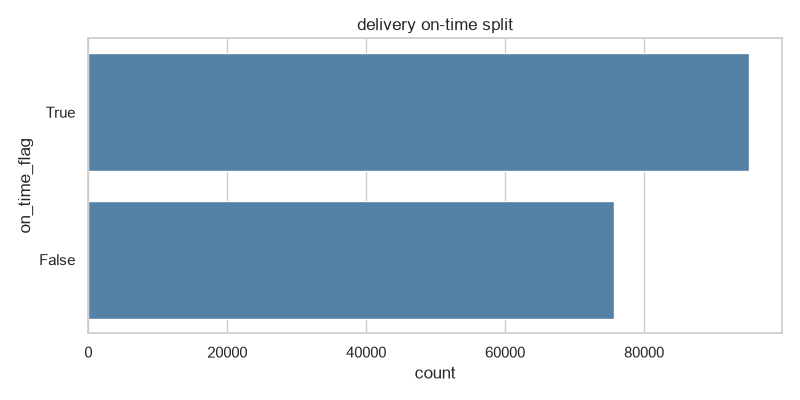

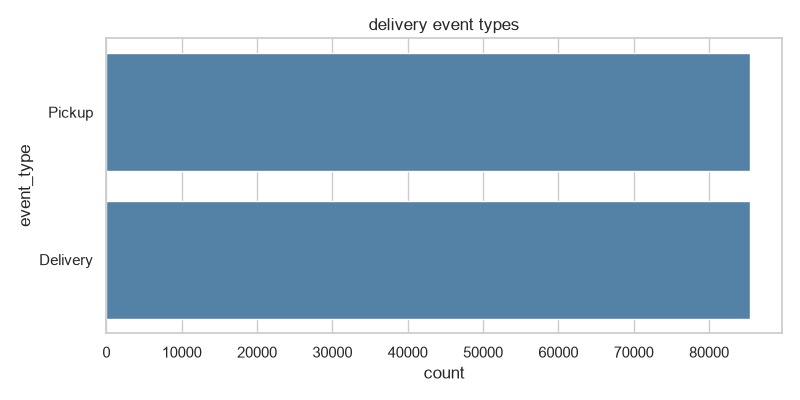

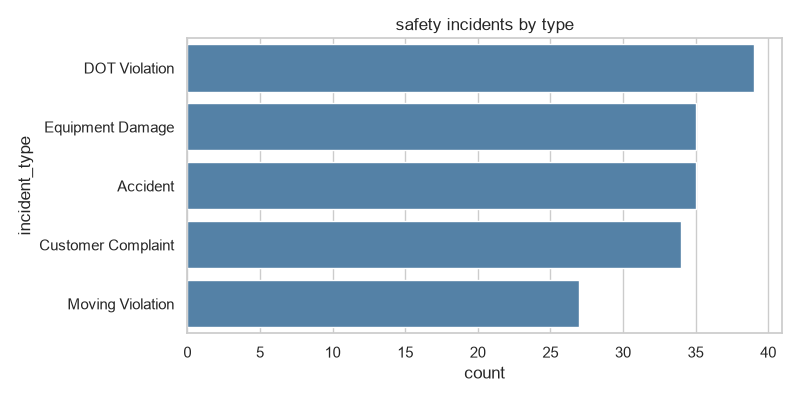

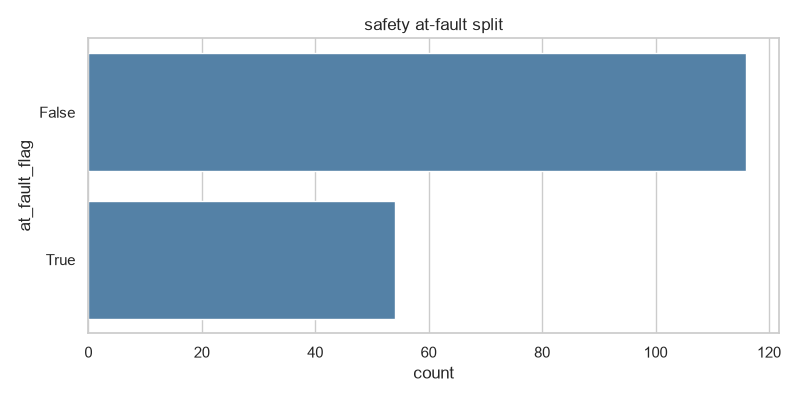

In [7]:
# categorical splits: on-time, event types, incident types, fault flags
def countplot(frame, column, title, fname):
    order = frame[column].value_counts().head(12).index
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=frame, y=column, order=order, ax=ax, color='steelblue')
    ax.set_title(title)
    fig.tight_layout()
    path = PLOTS / fname
    fig.savefig(path, dpi=100)
    plt.close(fig)
    display(Image(str(path)))


countplot(ev, 'on_time_flag', 'delivery on-time split', 'counts_on_time.png')
countplot(ev, 'event_type', 'delivery event types', 'counts_event_type.png')
countplot(si, 'incident_type', 'safety incidents by type', 'counts_incident_type.png')
countplot(si, 'at_fault_flag', 'safety at-fault split', 'counts_at_fault.png')

In [8]:
# loaded_at verdict plus stats snapshot for the report
for name, frame in frames.items():
    col = frame.get('loaded_at')
    stats[name]['loaded_at'] = {'null_pct': round(float(col.isna().mean()) * 100, 2), 'uniques': int(col.nunique())}
    print(name, stats[name]['loaded_at'])
(ROOT / 'notebooks' / 'stats_mongo.json').write_text(json.dumps(stats, indent=1, default=str))
print('saved stats_mongo.json')

delivery_events {'null_pct': 0.0, 'uniques': 1}
maintenance_records {'null_pct': 0.0, 'uniques': 1}
safety_incidents {'null_pct': 0.0, 'uniques': 1}
saved stats_mongo.json
